In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Dynamic Pricing using Gaussian Processes

In [2]:
class PricingEnvironment:
    def __init__(self, conversion_probability, cost):
        self.conversion_probability = conversion_probability
        self.cost = cost

    def round(self, p_t, n_t):
        d_t = np.random.binomial(n_t, self.conversion_probability(p_t))
        r_t = (p_t - self.cost)*d_t
        return d_t, r_t
    
    

### Dynamic pricing is an example of bandit problem with additional structure. 

### In standard Multi-Armed Bandits, actions are assumed to be independent, and there is no structure among them. In pricing applications, it is customary to assume that similar prices will lead to similar outcomes, thus there is some sort of "smoothness" in the reward function. Moreover, actions naturally belong to an infinite set (even though prices can be discretized to the cent, such a large number can be considered infinite).

## Gaussian Processes

### Gaussian Processes model a set of observations as multivariate normals.

### They rely on a _kernel_, that is an operator that quantifies the covariance between two samples. Using this covariance notion, we are able to estimate uncertainty simultaneously on all points. We will focus on one of the most common kernels: Radial Basis Function Kernel (RBF).

In [3]:
class RBFGaussianProcess:
    def __init__(self, scale=1, reg=1e-2):
        self.scale = scale # it's used in the Kernel only
        self.reg = reg
        self.k_xx_inv = None

    def rbf_kernel_incr_inv(self, B, C, D):
        temp = np.linalg.inv(D - C @ self.k_xx_inv @ B)
        block1 = self.k_xx_inv + self.k_xx_inv @ B @ temp @ C @ self.k_xx_inv
        block2 = - self.k_xx_inv @ B @ temp
        block3 = - temp @ C @ self.k_xx_inv
        block4 = temp
        res1 = np.concatenate((block1, block2), axis=1)
        res2 = np.concatenate((block3, block4), axis=1)
        res = np.concatenate((res1, res2), axis=0)
        return res

    def rbf_kernel(self, a, b):
        a_ = a.reshape(-1, 1)
        b_ = b.reshape(-1, 1)
        output = -1 * np.ones((a_.shape[0], b_.shape[0]))
        for i in range(a_.shape[0]):
            output[i, :] = np.power(a_[i] - b_, 2).ravel()
        return np.exp(-self.scale * output)
    
    def fit(self, x=np.array([]), y=np.array([])):
        x,y = np.array(x),np.array(y)
        if self.k_xx_inv is None:
            self.y = y.reshape(-1,1)
            self.x = x.reshape(-1,1)
            k_xx = self.rbf_kernel(self.x, self.x) + self.reg * np.eye(self.x.shape[0])
            self.k_xx_inv = np.linalg.inv(k_xx)
        else:
            B = self.rbf_kernel(self.x, x)
            self.x = np.vstack((self.x, x))
            self.y = np.vstack((self.y, y))
            self.k_xx_inv = self.rbf_kernel_incr_inv(B, B.T, np.array([1 + self.reg]))

        return self

    def predict(self, x_predict):
        k = self.rbf_kernel(x_predict, self.x)

        mu_hat = k @ self.k_xx_inv @ self.y
        sigma_hat = 1 - np.diag(k @ self.k_xx_inv @ k.T)

        return mu_hat.ravel(), sigma_hat.ravel()


### For a reference on Gaussian Processes and Bandits see https://arxiv.org/pdf/1704.00445.pdf

### Visualizing the Kernel $ k(x,x') = \exp(-s(x-x')^2)$

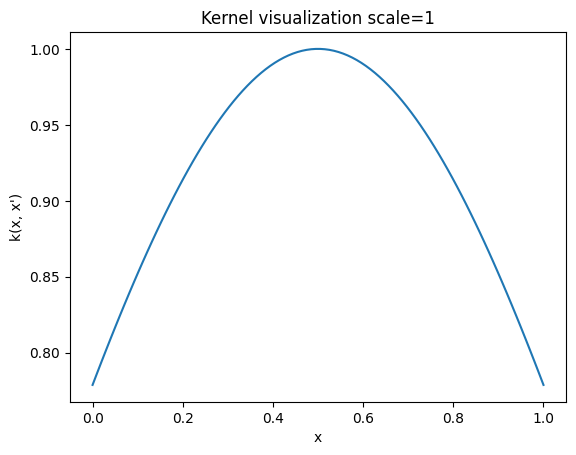

In [21]:
scale = 1
gp = RBFGaussianProcess(scale=scale) # scale influences the kernel
x = np.array([0.5])
xs = np.linspace(0, 1, 100) 
k_xxp = gp.rbf_kernel(x,xs).flatten()
plt.plot(xs, k_xxp)
plt.xlabel("x")
plt.ylabel("k(x, x')")
plt.title("Kernel visualization scale={}".format(scale))
plt.show()

### Our demand curve:

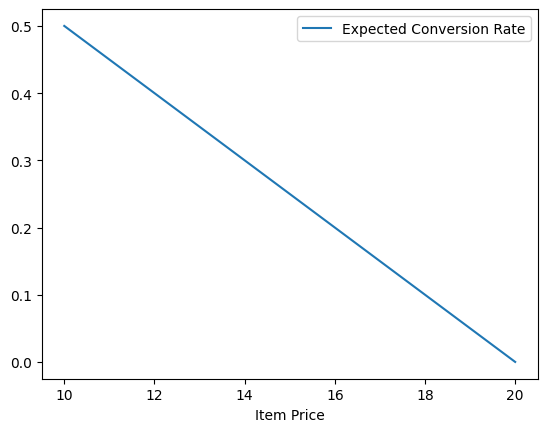

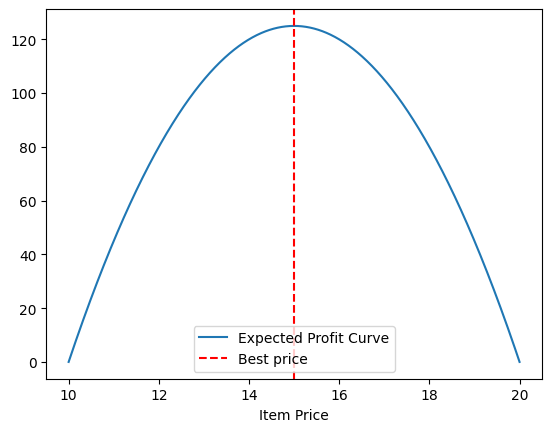

In [5]:
cost = 10
conversion_probability = lambda p: 1-p/20
n_customers = 100 # I assume the number of customers arriving is the same everyday (for now, in general this is not true)

all_prices = np.linspace(10, 20, 1000)
expected_profit_curve = n_customers*conversion_probability(all_prices)*(all_prices-cost)
best_price = all_prices[np.argmax(expected_profit_curve)]

plt.figure()
plt.plot(all_prices, conversion_probability(all_prices), label='Expected Conversion Rate')
plt.xlabel('Item Price')
plt.legend()
plt.show()

plt.figure()
plt.plot(all_prices, expected_profit_curve, label='Expected Profit Curve')
plt.axvline(best_price, color='red', linestyle='--', label='Best price')
plt.xlabel('Item Price')
plt.legend()
plt.show()

### Given a set of (price, sales) observations, how can I use GPs to model the demand curve?

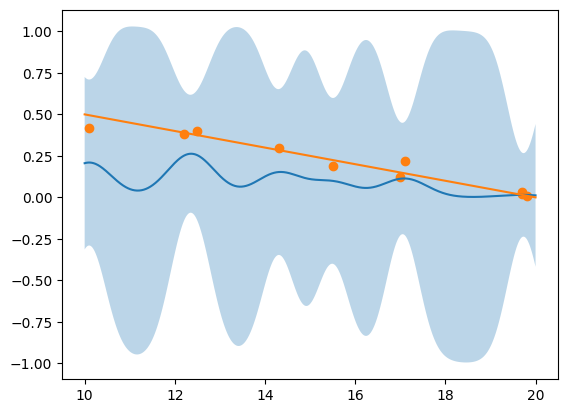

In [6]:
cost = 10
conversion_probability = lambda p: 1-p/20
n_customers = 100 # I assume the number of customers arriving is the same everyday (for now, in general this is not true)

np.random.seed(4)
price_range = np.linspace(10,20,1000)
price_samples = 10 + 10 * np.random.sample(size=10).round(2) # randomly generating prices

# GP works well if the samples are in [0,1], thus we normalize them
# by doing this, we are estimating the conversion probability
normalized_sales_samples = np.random.binomial(n_customers, conversion_probability(price_samples))/n_customers

gp = RBFGaussianProcess(scale=2,reg=1)

gp.fit(price_samples, normalized_sales_samples)

mu, sigma = gp.predict(price_range)

plt.figure()
plt.plot(price_range, mu, label='estimated average')
plt.fill_between(price_range, mu-sigma, mu+sigma, alpha=0.3)
plt.scatter(price_samples, normalized_sales_samples, color='C1')
plt.plot(price_range, conversion_probability(price_range), label='true conversion rate')
plt.show()

### Sequential Update:

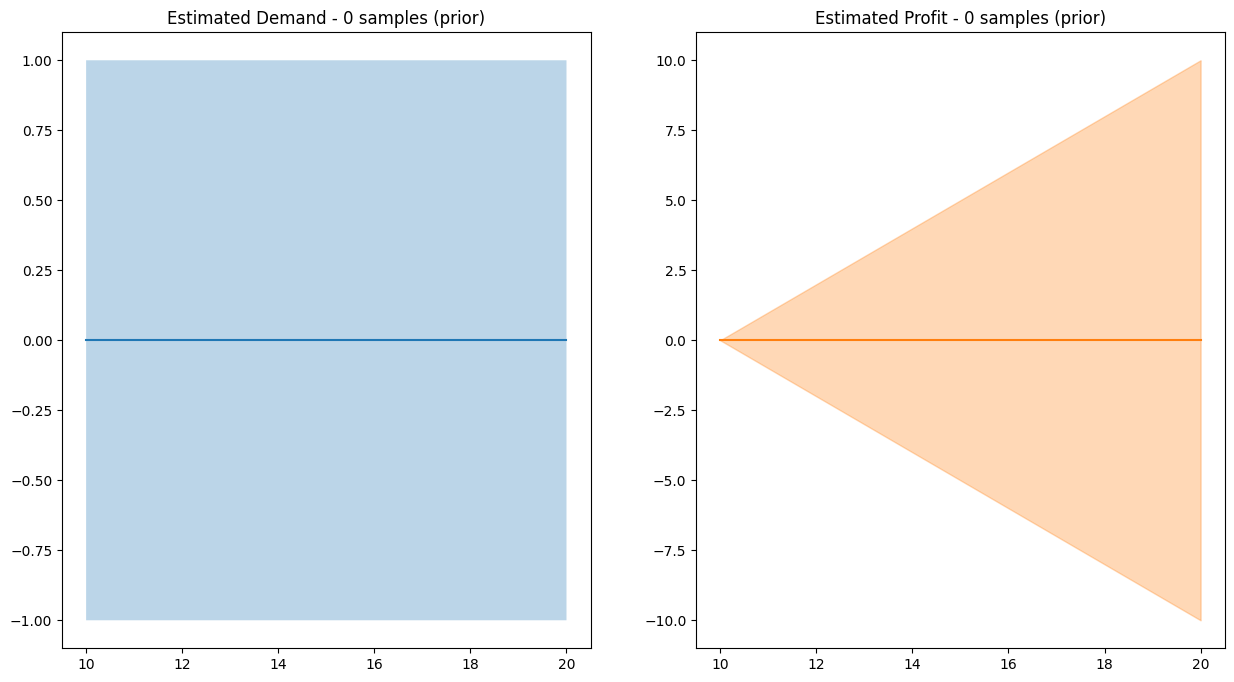

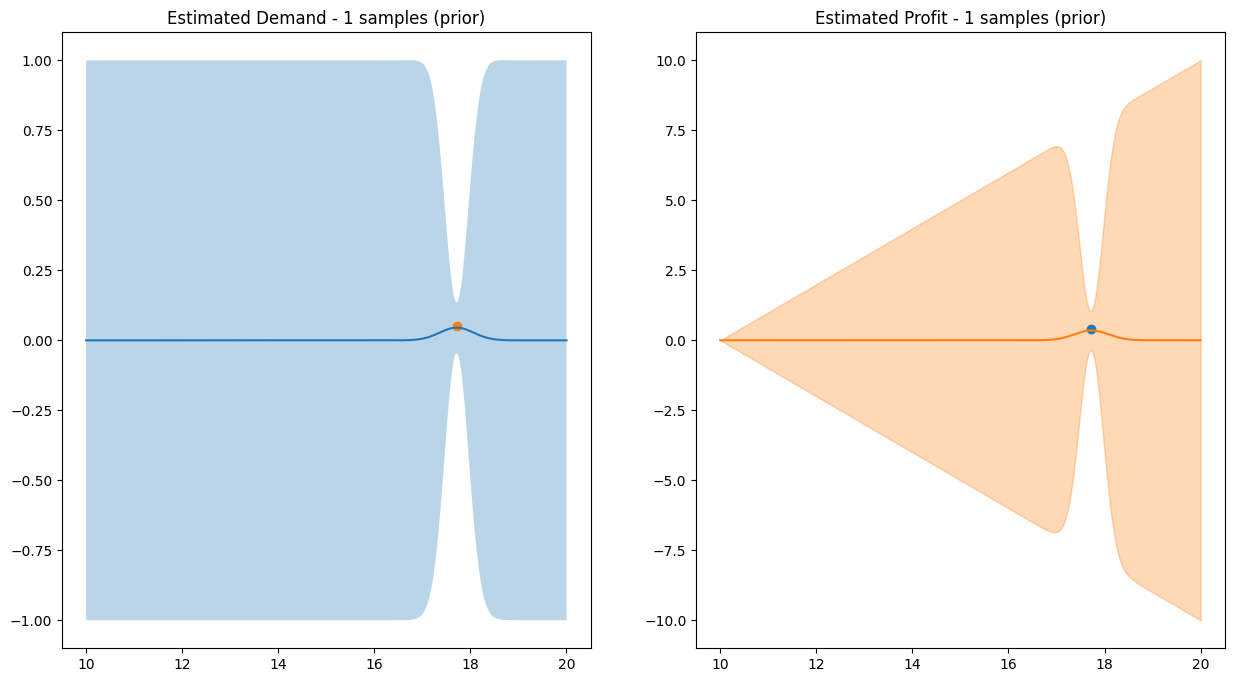

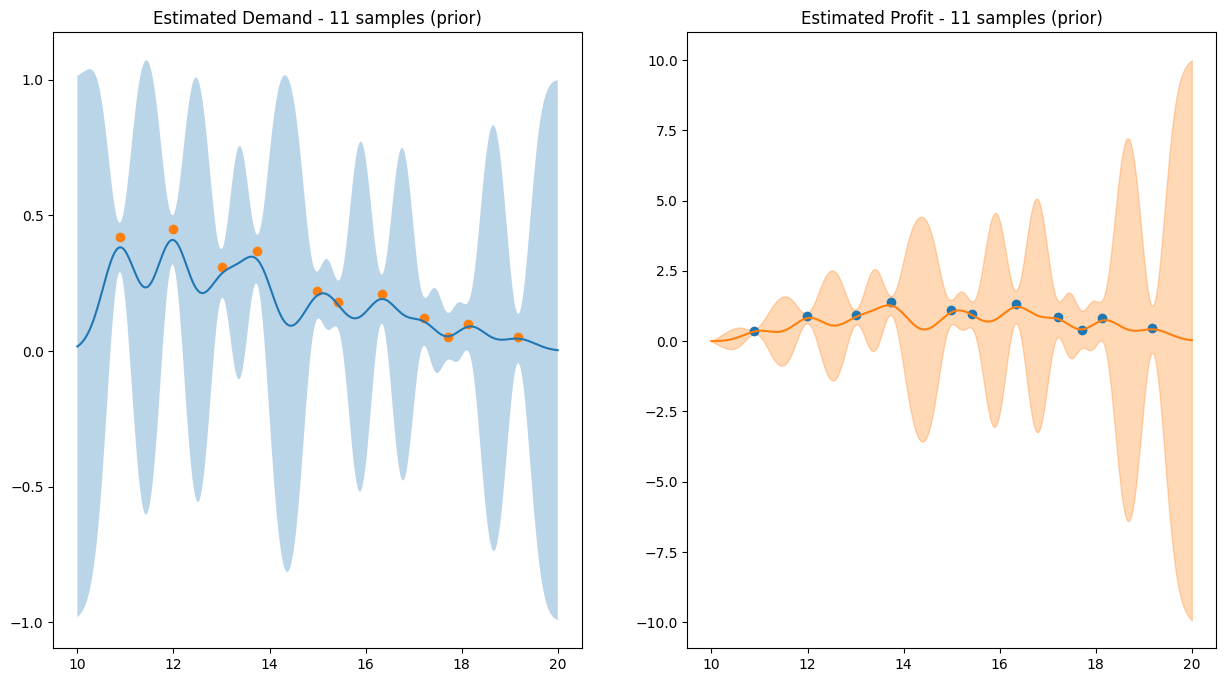

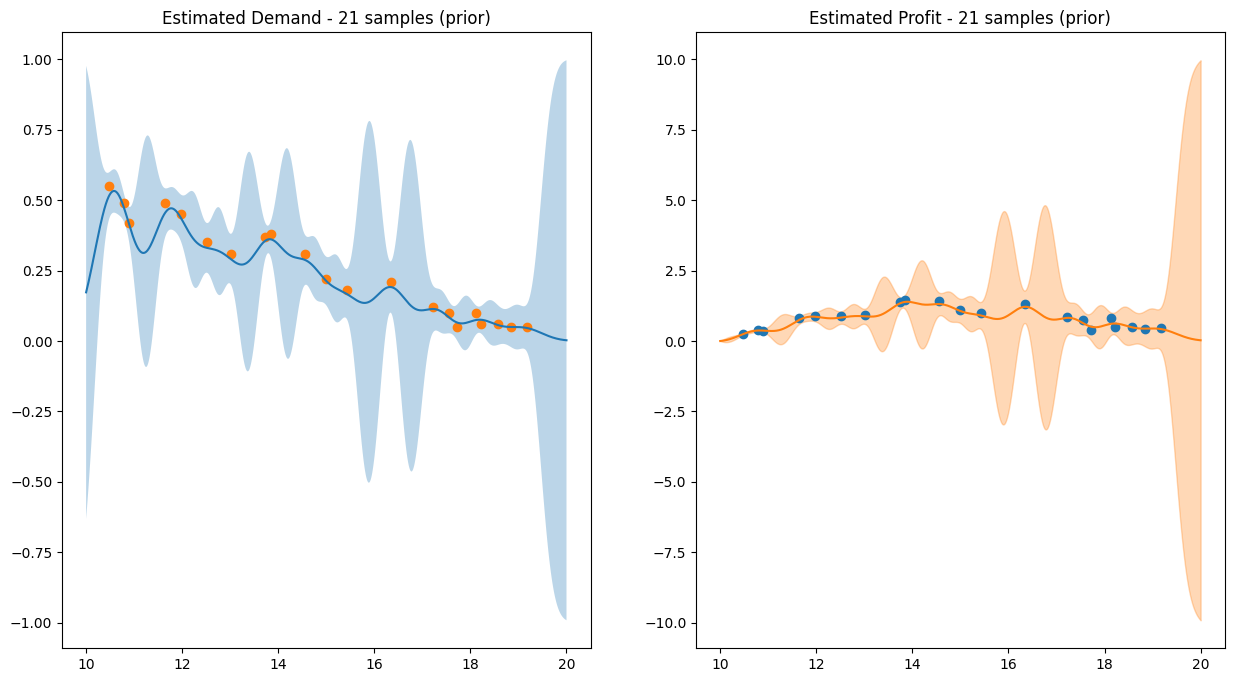

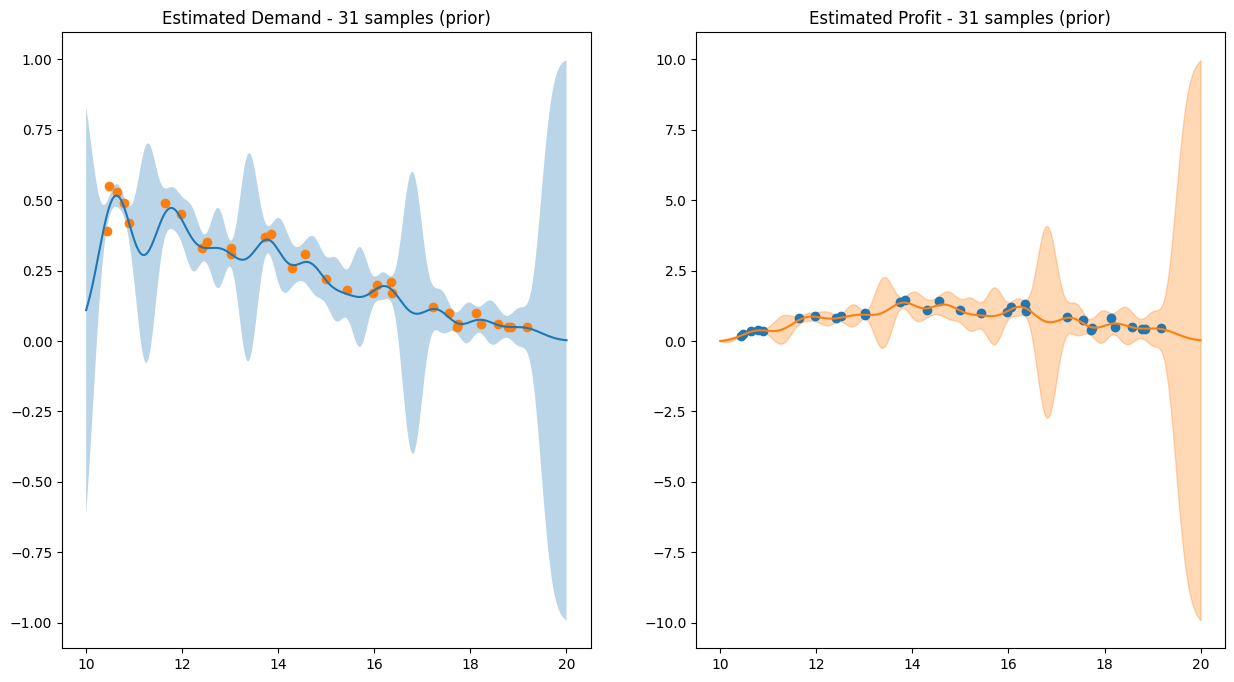

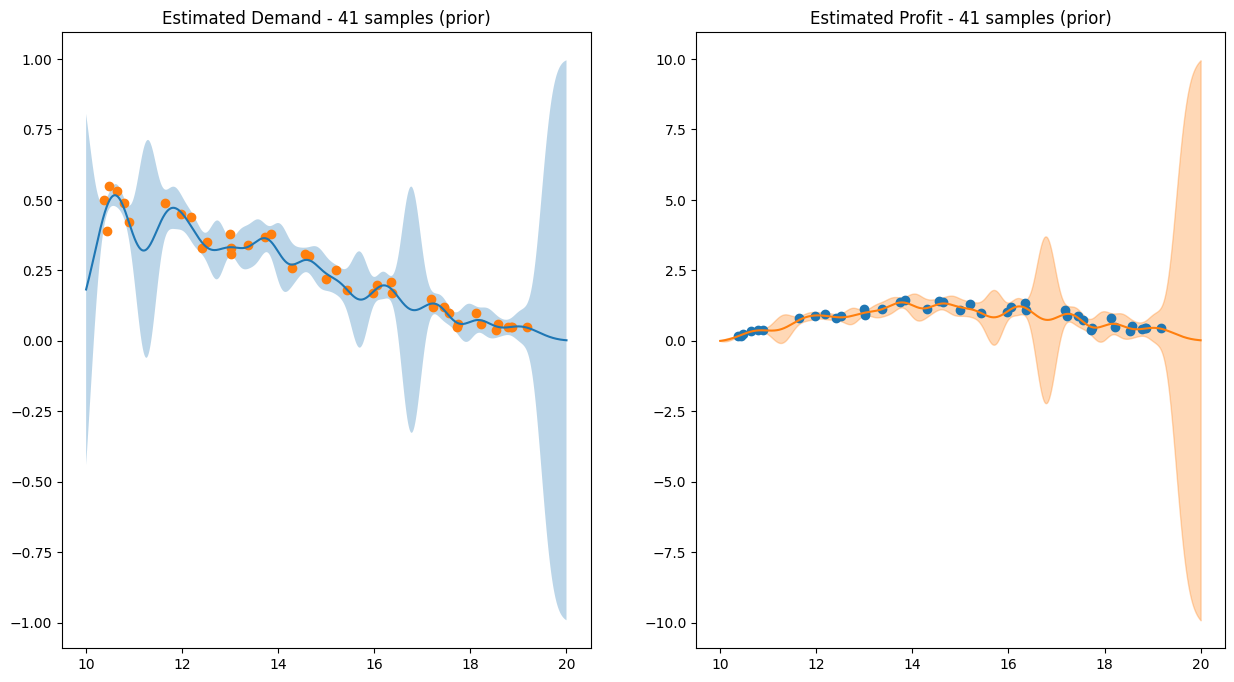

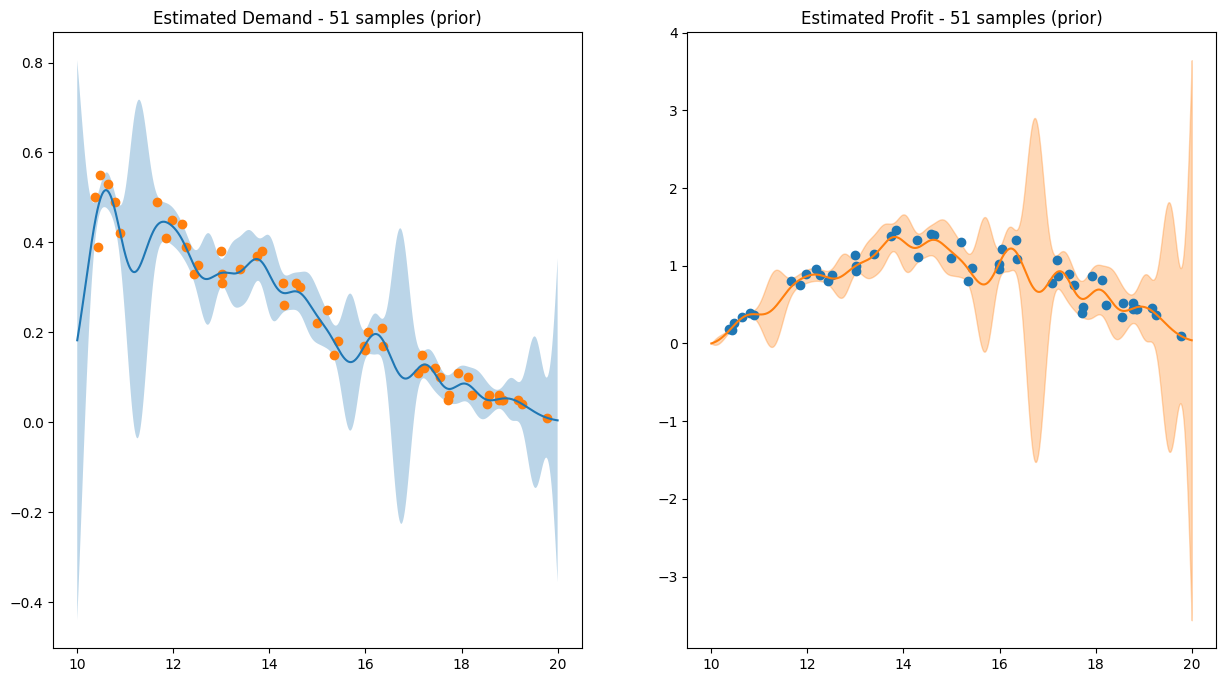

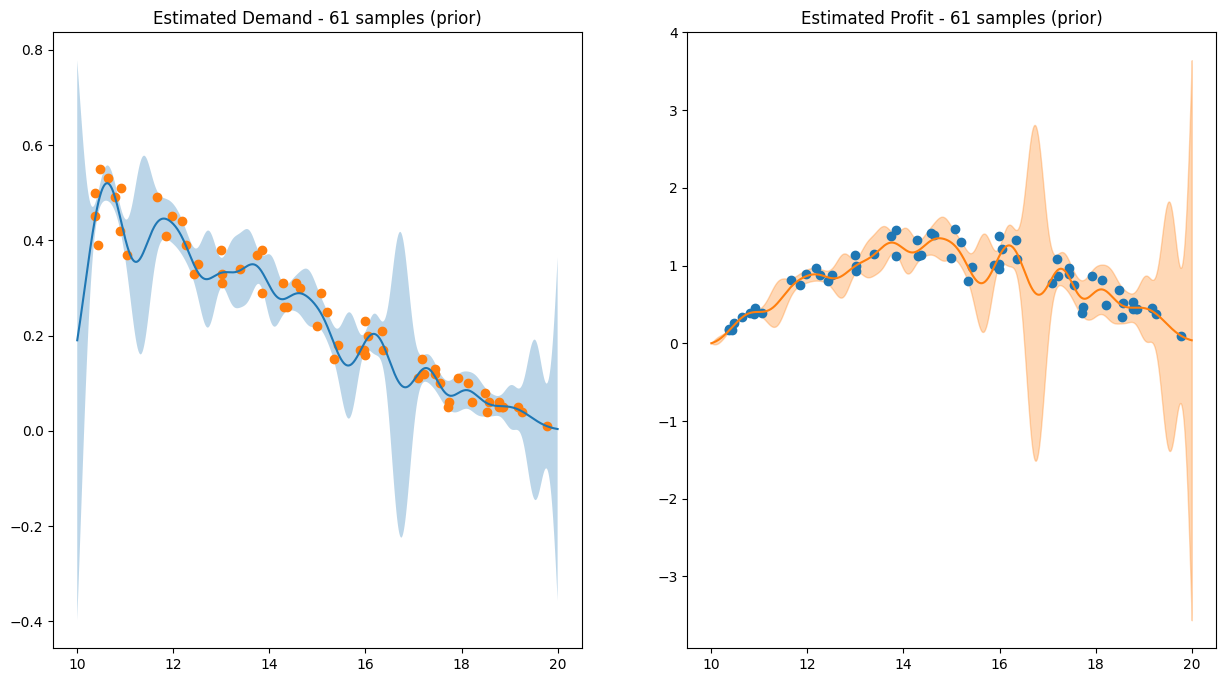

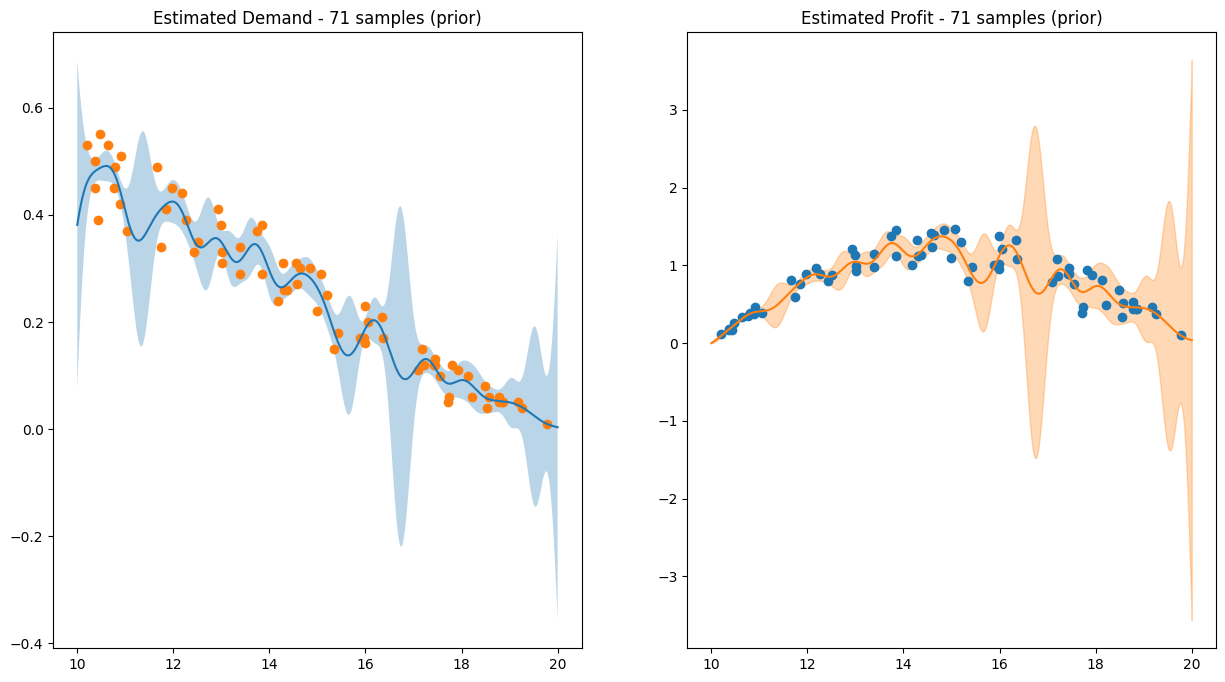

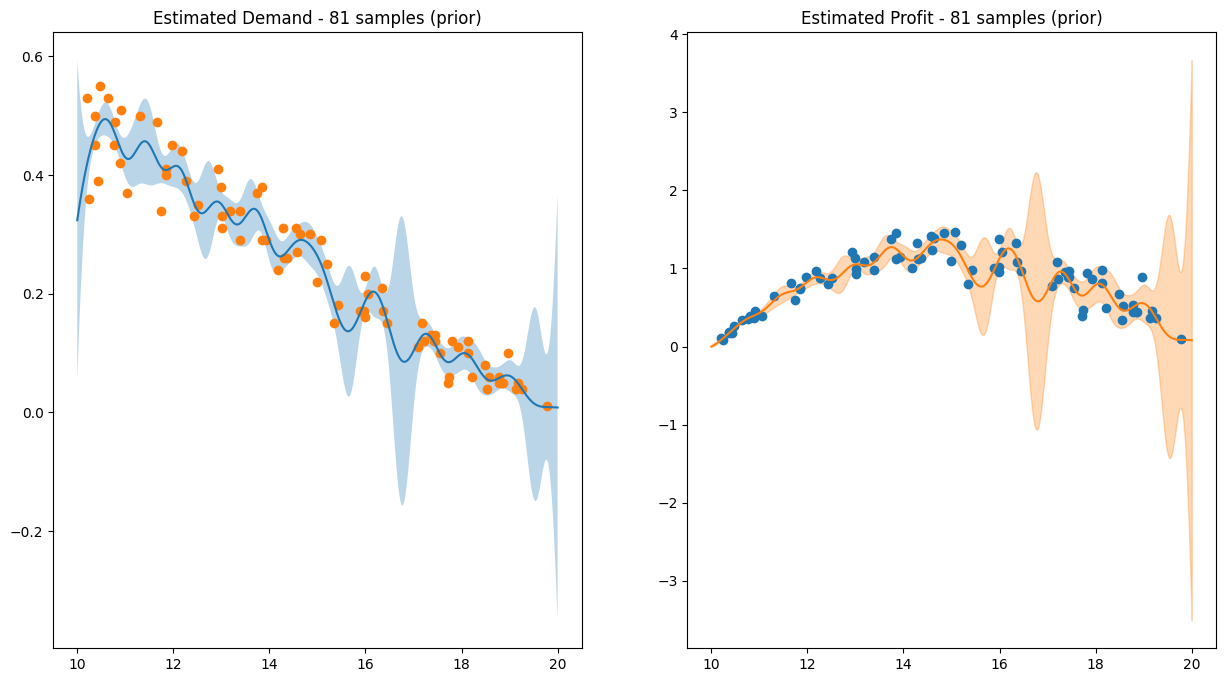

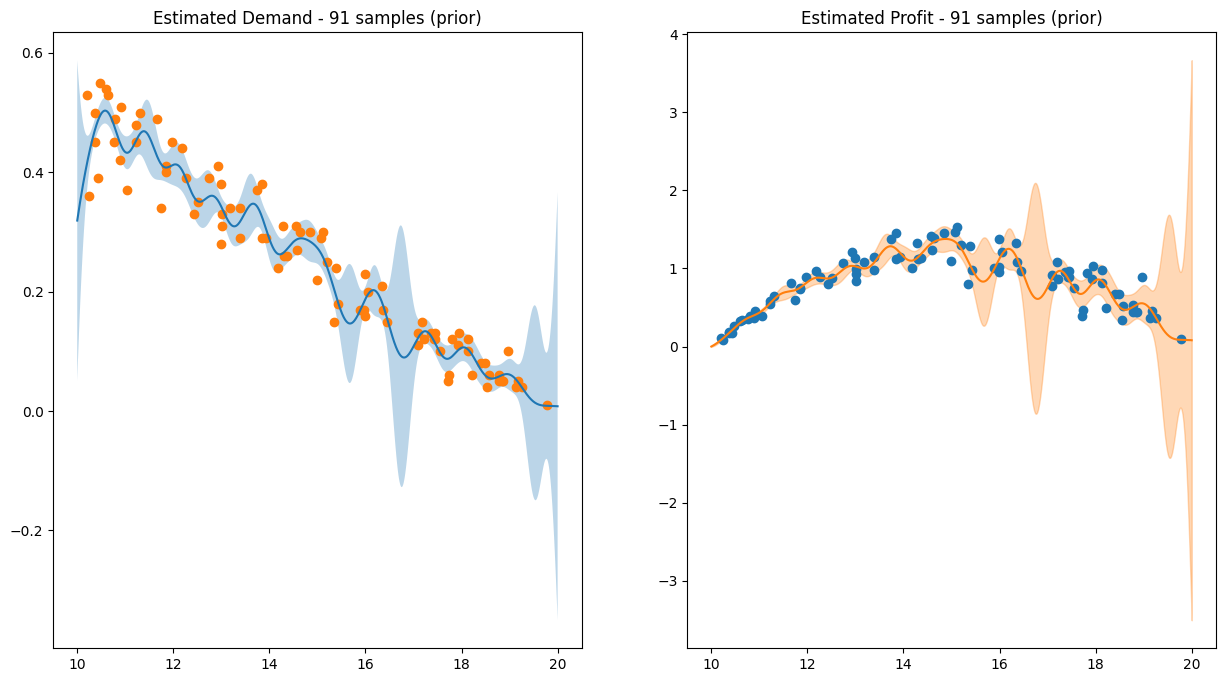

In [7]:
np.random.seed(10)
price_samples, normalized_sales_samples =  np.zeros(100), np.zeros(100)
cost = 10

gp = RBFGaussianProcess(scale=4,reg=0.1).fit() # play with these aprameters
# gp = RBFGaussianProcess(scale=4,reg=0.1).fit() # play with these aprameters
mu, sigma = gp.predict(price_range)
profit_mu, profit_sigma = mu*(price_range-cost), sigma*(price_range-cost)

f,ax = plt.subplots(1,2, figsize=(15,8))
ax[0].plot(price_range, mu)
ax[0].fill_between(price_range, mu-sigma, mu+sigma, alpha=0.3)
ax[0].set_title('Estimated Demand - 0 samples (prior)')
ax[1].plot(price_range, profit_mu, color='C1')
ax[1].fill_between(price_range, profit_mu-profit_sigma, profit_mu+profit_sigma, alpha=0.3, color='C1')
ax[1].set_title('Estimated Profit - 0 samples (prior)')
plt.show()

for i in range(100):
    p = np.random.sample()*10 + 10 # select a price randomly
    s = np.random.binomial(n_customers, conversion_probability(p))/n_customers # a sample of the conversion probability

    price_samples[i] = p
    normalized_sales_samples[i] = s

    gp.fit(p, s)

    if i%10==0 :
        mu, sigma = gp.predict(price_range)
        profit_mu, profit_sigma = mu*(price_range-cost), sigma*(price_range-cost) #estimated profit for customer

        f,ax = plt.subplots(1,2, figsize=(15,8))
        ax[0].plot(price_range, mu)
        ax[0].fill_between(price_range, mu-sigma, mu+sigma, alpha=0.3)
        ax[0].set_title(f'Estimated Demand - {i+1} samples (prior)')
        ax[0].scatter(price_samples[:i+1], normalized_sales_samples[:i+1])
        ax[1].plot(price_range, profit_mu, color='C1')
        ax[1].fill_between(price_range, profit_mu-profit_sigma, profit_mu+profit_sigma, alpha=0.3, color='C1')
        ax[1].set_title(f'Estimated Profit - {i+1} samples (prior)')
        ax[1].scatter(price_samples[:i+1], normalized_sales_samples[:i+1]*(price_samples[:i+1]-cost))
        plt.show()

### Idea: why don't we choose the price having the largest potential profit? -> GP-UCB

## The GP-UCB Algorithm

### GP-UCB uses the Optimism principle just like UCB1. However, UCB1 doesn't consider how rewards from different actions may be related, while GP-UCB does so. The upper confidence bound is computed by summing the average of the GP estimation plus a term which accounts for the estimation uncertainty

In [8]:
# From the agent's point of view, action set is [0,1]. If the actual actions are outside this
# set, we can always perform a rescaling outside the class.
class GPUCBAgent:
    def __init__(self, T, discretization=100, scale=2, reg=0.25):
        self.T = T
        self.arms = np.linspace(0, 1, discretization)
        self.gp = RBFGaussianProcess(scale=scale, reg=reg).fit()
        self.a_t = None
        self.action_hist = np.zeros(T)
        self.reward_hist = np.zeros(T)
        self.mu_t = np.zeros(discretization)
        self.sigma_t = np.zeros(discretization)
        self.gamma = lambda t: np.log(t+1)**2 
        self.beta = lambda t: 1 + 0.5*np.sqrt(2 * (self.gamma(t) + 1 + np.log(T)))
        self.N_pulls = np.zeros(discretization)
        self.t = 0
    
    def pull_arm(self):
        self.mu_t, self.sigma_t = self.gp.predict(self.arms) 
        ucbs = self.mu_t + self.beta(self.t) * self.sigma_t
        self.a_t = np.argmax(ucbs)
        return self.arms[self.a_t]
    
    def update(self, r_t):
        self.N_pulls[self.a_t] += 1
        self.action_hist[self.t] = self.arms[self.a_t]
        self.reward_hist[self.t] = r_t
        self.gp = self.gp.fit(self.arms[self.a_t], r_t)
        self.t += 1

#### $UCB_t(a) = \mu_{t-1}(a) + \beta_t\sigma_{t-1}(a)$, for $ a\in [0,1]$ (continuous action set).

### $\beta_t$ is the parameter governing exploration. It accounts for two main factors: $\gamma_t$, which represents the maximum information that can be gained at round $t$, and a term in the order of $\mathcal{O}(\sqrt{\log(T)})$ that incentivizes exploration (in a similar way as UCB1). Formally:
### $$\beta_t = B +R\sqrt{2(\gamma_{t-1}+1+\ln(1/\delta))} $$, where:
- ### $B$ is (roughly) an upper bound on the $r_t$
- ### $R$ is (roughly) the variance of the noise
- ### $\gamma_{t-1}$ is the maximum information gain at $t$, $\gamma_{t} \le O(\ln(t)^{d+1})$
- ### $\delta \in (0,1)$ is a confidence parameter, usually $1/T$

### GPs work bettern when domain and codomain are [0,1], thus we normalize

Last value of beta: 5.78856969848345
(500,)


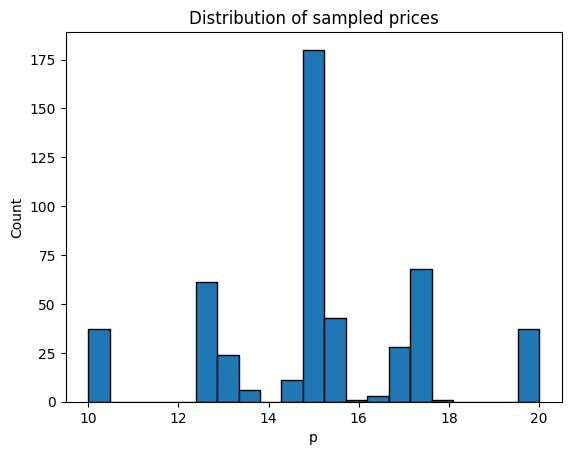

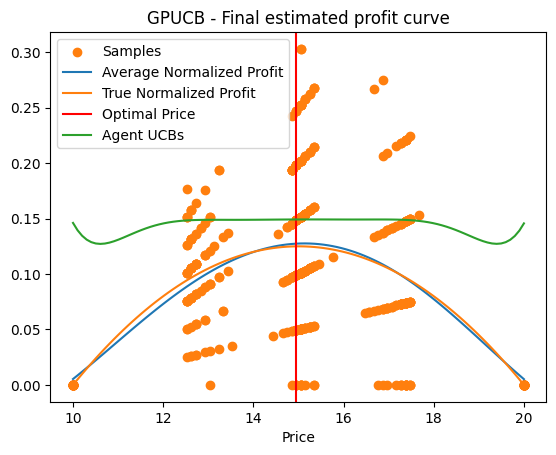

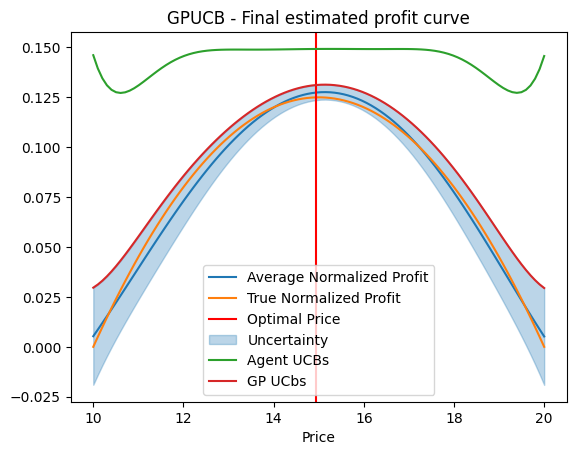

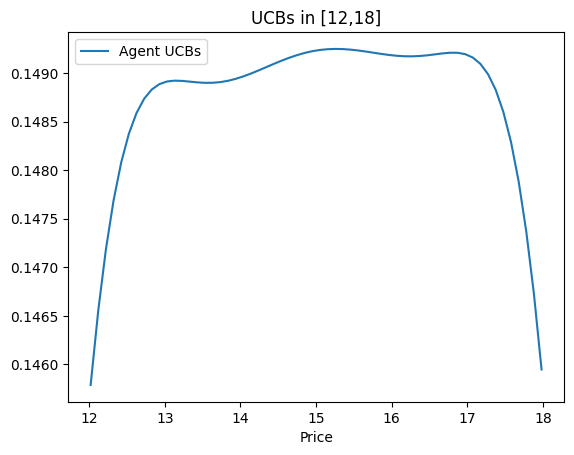

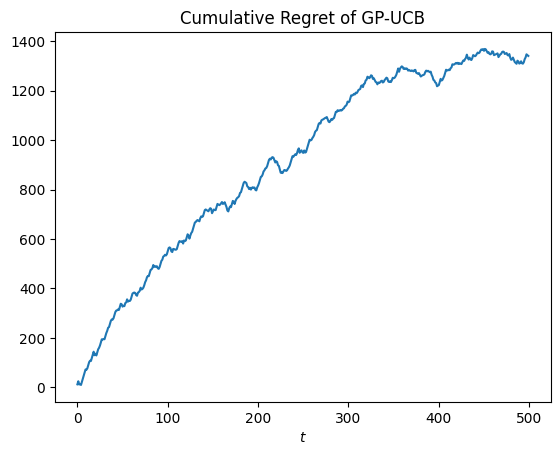

In [9]:
def rescale(x, min_x, max_x):
    return min_x + (max_x-min_x)*x
prices = np.linspace(10,20,100) # for computational purposes we need to discretize the action space
conversion_probability = lambda p: 1-p/20
reward_function = lambda price, n_sales: (price-cost)*n_sales
maximum_profit = reward_function(max(prices), n_customers) # the maximum possible reward is selling at the maximum price to every possible customer

T = 500
# T = 5
min_price, max_price = 10, 20
n_customers = 10 #small number of customers
cost = 10
# play with this parameters
scale = 4
reg = 1
agent = GPUCBAgent(T, scale=scale, reg=reg) 
np.random.seed(4)
env = PricingEnvironment(conversion_probability=conversion_probability, cost=cost)

# let's compute the clairvoyant
prices = np.linspace(min_price, max_price, 100)
profit_curve = reward_function(prices, n_customers*conversion_probability(prices))
best_price_index = np.argmax(profit_curve)
best_price = prices[best_price_index]
expected_clairvoyant_rewards = np.repeat(profit_curve[best_price_index], T)

agent_rewards = []
for t in range(T):
    p_t = agent.pull_arm()
    p_t = rescale(p_t, min_price, max_price)
    d_t, r_t = env.round(p_t, n_t=n_customers)
    agent.update((r_t/max(prices-cost))/n_customers) # normalized in [0,1]
    agent_rewards.append(r_t)

cumulative_regret = np.cumsum(expected_clairvoyant_rewards-agent_rewards)

agent_mu_t, agent_sigma_t = agent.gp.predict(agent.arms) 
agent_ucbs = agent_mu_t + agent.beta(T) * agent_sigma_t
print('Last value of beta:',agent.beta(T))

sampled_prices = rescale(agent.action_hist, min_price, max_price)
print(sampled_prices.shape)
profits = agent.reward_hist
gp = RBFGaussianProcess(scale=scale, reg=reg)
# gp.fit(sampled_prices, profits)
# mu, sigma = gp.predict(np.linspace(10,20,100))
gp.fit(agent.action_hist, profits)
mu, sigma = gp.predict(np.linspace(0,1,100))

plt.hist(sampled_prices, bins=21, range=(10, 20), edgecolor='black')
plt.xlabel('p')
plt.ylabel('Count')
plt.title('Distribution of sampled prices')
plt.show()

plt.scatter(sampled_prices, profits, label='Samples', color='C1')
plt.plot(np.linspace(10,20,100), mu, label='Average Normalized Profit')
plt.plot(np.linspace(10,20,100), (np.linspace(10,20,100)-cost)*conversion_probability(np.linspace(10,20,100))/(max(prices-cost)), label='True Normalized Profit')
plt.axvline(best_price, color='red',label='Optimal Price')
# plt.fill_between(np.linspace(10,20,100), mu-sigma, mu+sigma, alpha=0.3, label='Uncertainty', color='C0')
plt.plot(np.linspace(10,20,len(agent.arms)), agent_ucbs, label='Agent UCBs')
# plt.plot(np.linspace(10,20,len(agent.arms)), agent_mu_t + agent_sigma_t, label='GP UCbs')
plt.title('GPUCB - Final estimated profit curve')
plt.xlabel('Price')
plt.legend()
plt.show()

plt.plot(np.linspace(10,20,100), mu, label='Average Normalized Profit')
plt.plot(np.linspace(10,20,100), (np.linspace(10,20,100)-cost)*conversion_probability(np.linspace(10,20,100))/(max(prices-cost)), label='True Normalized Profit')
plt.axvline(best_price, color='red',label='Optimal Price')
plt.fill_between(np.linspace(10,20,100), mu-sigma, mu+sigma, alpha=0.3, label='Uncertainty', color='C0')
plt.plot(np.linspace(10,20,len(agent.arms)), agent_ucbs, label='Agent UCBs')
plt.plot(np.linspace(10,20,len(agent.arms)), agent_mu_t + agent_sigma_t, label='GP UCbs')
plt.title('GPUCB - Final estimated profit curve')
plt.xlabel('Price')
plt.legend()
plt.show()

p_min_prime = 12
p_max_prime = 18
a = (p_min_prime - 10) / (20 - 10)
b = (p_max_prime - 10) / (20 - 10)
mask = (agent.arms >= a) & (agent.arms <= b)
prices_zoom = 10 + agent.arms[mask] *(20-10)
plt.plot(prices_zoom, agent_ucbs[mask], label='Agent UCBs')
plt.title('UCBs in [{},{}]'.format(p_min_prime,p_max_prime))
plt.xlabel('Price')
plt.legend()
plt.show()


plt.figure()
plt.plot(cumulative_regret)
plt.title('Cumulative Regret of GP-UCB')
plt.xlabel('$t$')
plt.show()

### Main drawback of this strategy: computational burden!

### The algorithm seems to perform better than a UCB1 strategy with price discretization, but we need a more reliable estimation

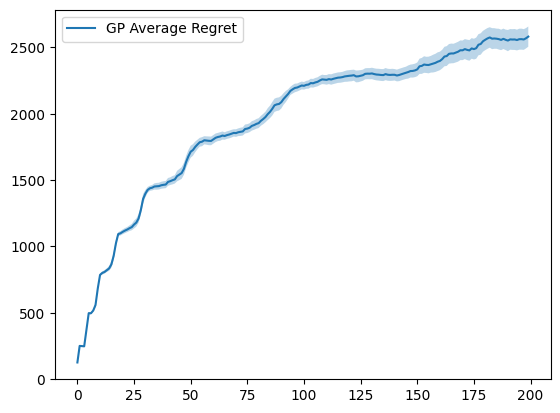

In [10]:
conversion_probability = lambda p: 1-p/20
reward_function = lambda price, n_sales: (price-cost)*n_sales

T = 200

min_price, max_price = 10, 20
n_customers = 100
cost = 10

scale = 2
reg = max(0.2,10/n_customers)

prices = np.linspace(min_price, max_price, 100)

# let's compute the clairvoyant
many_prices = np.linspace(min_price, max_price, 1000)
profit_curve = reward_function(many_prices, n_customers*conversion_probability(many_prices))
best_price_index = np.argmax(profit_curve)
best_price = many_prices[best_price_index]
expected_clairvoyant_rewards = np.repeat(profit_curve[best_price_index], T)

n_epochs = 20

gp_all_cumulative_regrets = []
for i in range(n_epochs):
    gp_agent = GPUCBAgent(T,scale=scale,reg=reg)

    np.random.seed(10*i)
    env = PricingEnvironment(conversion_probability=conversion_probability, cost=cost)

    gp_agent_rewards = []
    for t in range(T):
        p_t = gp_agent.pull_arm()
        p_t = rescale(p_t, min_price, max_price)
        d_t, r_t = env.round(p_t, n_t=n_customers)
        normalized_r_t = (r_t/max(prices-cost))/n_customers # normalized in [0,1]
        gp_agent.update(normalized_r_t)
        gp_agent_rewards.append(r_t)

    gp_all_cumulative_regrets.append(np.cumsum(expected_clairvoyant_rewards-gp_agent_rewards))


gp_all_cumulative_regrets = np.array(gp_all_cumulative_regrets)
gp_average_cumulative_regret = gp_all_cumulative_regrets.mean(axis=0)
gp_cumulative_regret_std = gp_all_cumulative_regrets.std(axis=0)

plt.plot(np.arange(T), gp_average_cumulative_regret, label='GP Average Regret')
plt.fill_between(np.arange(T),
                gp_average_cumulative_regret-gp_cumulative_regret_std/np.sqrt(n_epochs),
                gp_average_cumulative_regret+gp_cumulative_regret_std/np.sqrt(n_epochs),
                alpha=0.3)
plt.legend()
plt.show()

### How does it change if I change the number of customers? And if I change the conversion rate?

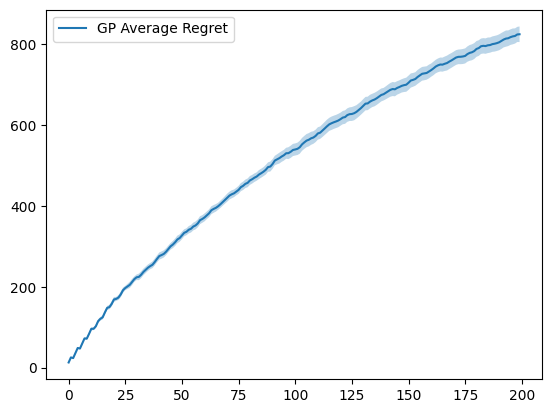

In [11]:
conversion_probability = lambda p: 1-p/20
reward_function = lambda price, n_sales: (price-cost)*n_sales

T = 200

min_price, max_price = 10, 20
n_customers = 10
cost = 10

scale = 2
reg = max(0.2,10/n_customers)

prices = np.linspace(min_price, max_price, 100)

# let's compute the clairvoyant
many_prices = np.linspace(min_price, max_price, 1000)
profit_curve = reward_function(many_prices, n_customers*conversion_probability(many_prices))
best_price_index = np.argmax(profit_curve)
best_price = many_prices[best_price_index]
expected_clairvoyant_rewards = np.repeat(profit_curve[best_price_index], T)

n_epochs = 20

gp_all_cumulative_regrets = []
for i in range(n_epochs):
    gp_agent = GPUCBAgent(T,scale=scale,reg=reg)

    np.random.seed(10*i)
    env = PricingEnvironment(conversion_probability=conversion_probability, cost=cost)

    gp_agent_rewards = []
    for t in range(T):
        p_t = gp_agent.pull_arm()
        p_t = rescale(p_t, min_price, max_price)
        d_t, r_t = env.round(p_t, n_t=n_customers)
        normalized_r_t = (r_t/max(prices-cost))/n_customers # normalized in [0,1]
        gp_agent.update(normalized_r_t)
        gp_agent_rewards.append(r_t)

    gp_all_cumulative_regrets.append(np.cumsum(expected_clairvoyant_rewards-gp_agent_rewards))


gp_all_cumulative_regrets = np.array(gp_all_cumulative_regrets)
gp_average_cumulative_regret = gp_all_cumulative_regrets.mean(axis=0)
gp_cumulative_regret_std = gp_all_cumulative_regrets.std(axis=0)

plt.plot(np.arange(T), gp_average_cumulative_regret, label='GP Average Regret')
plt.fill_between(np.arange(T),
                gp_average_cumulative_regret-gp_cumulative_regret_std/np.sqrt(n_epochs),
                gp_average_cumulative_regret+gp_cumulative_regret_std/np.sqrt(n_epochs),
                alpha=0.3)
plt.legend()
plt.show()

### Can you compare directly the regret in the two cases above ($n = 100$ and $n=10$)?

### Now consider a different conversion rate

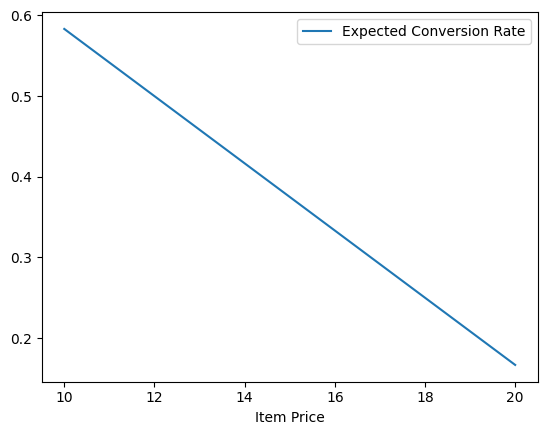

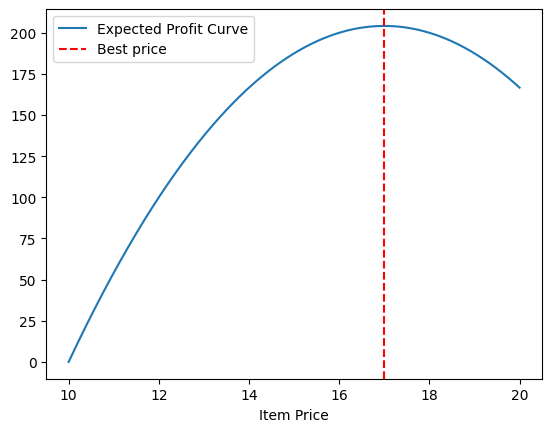

In [12]:
cost = 10
conversion_probability = lambda p: 1-p/24
n_customers = 100 # I assume the number of customers arriving is the same everyday (for now, in general this is not true)

all_prices = np.linspace(10, 20, 1000)
expected_profit_curve = n_customers*conversion_probability(all_prices)*(all_prices-cost)
best_price = all_prices[np.argmax(expected_profit_curve)]

plt.figure()
plt.plot(all_prices, conversion_probability(all_prices), label='Expected Conversion Rate')
plt.xlabel('Item Price')
plt.legend()
plt.show()

plt.figure()
plt.plot(all_prices, expected_profit_curve, label='Expected Profit Curve')
plt.axvline(best_price, color='red', linestyle='--', label='Best price')
plt.xlabel('Item Price')
plt.legend()
plt.show()

Last value of beta: 5.78856969848345


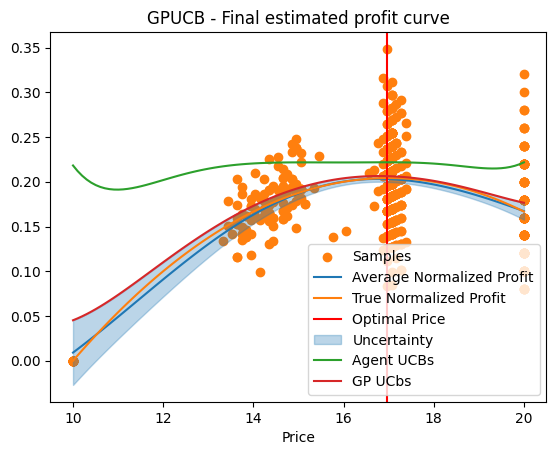

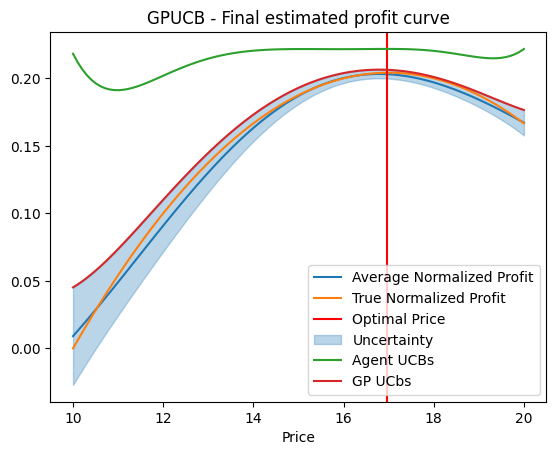

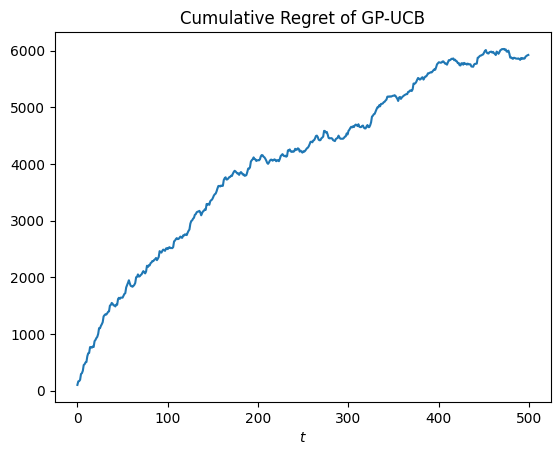

In [13]:
prices = np.linspace(10,20,100) # for computational purposes we need to discretize the action space
conversion_probability = lambda p: 1-p/24
reward_function = lambda price, n_sales: (price-cost)*n_sales
maximum_profit = reward_function(max(prices), n_customers) # the maximum possible reward is selling at the maximum price to every possible customer

T = 500
# T = 5
min_price, max_price = 10, 20
n_customers = 50
cost = 10
# play with this parameters
scale = 2
reg = 1
agent = GPUCBAgent(T, scale=scale, reg=reg) 
np.random.seed(2)
env = PricingEnvironment(conversion_probability=conversion_probability, cost=cost)

# let's compute the clairvoyant
prices = np.linspace(min_price, max_price, 100)
profit_curve = reward_function(prices, n_customers*conversion_probability(prices))
best_price_index = np.argmax(profit_curve)
best_price = prices[best_price_index]
expected_clairvoyant_rewards = np.repeat(profit_curve[best_price_index], T)

agent_rewards = []
for t in range(T):
    p_t = agent.pull_arm()
    p_t = rescale(p_t, min_price, max_price)
    d_t, r_t = env.round(p_t, n_t=n_customers)
    agent.update((r_t/max(prices-cost))/n_customers) # normalized in [0,1]
    agent_rewards.append(r_t)

cumulative_regret = np.cumsum(expected_clairvoyant_rewards-agent_rewards)

agent_mu_t, agent_sigma_t = agent.gp.predict(agent.arms) 
agent_ucbs = agent_mu_t + agent.beta(T) * agent_sigma_t
print('Last value of beta:',agent.beta(T))

sampled_prices = rescale(agent.action_hist, min_price, max_price)
profits = agent.reward_hist
gp = RBFGaussianProcess(scale=scale, reg=reg)
# gp.fit(sampled_prices, profits)
# mu, sigma = gp.predict(np.linspace(10,20,100))
gp.fit(agent.action_hist, profits)
mu, sigma = gp.predict(np.linspace(0,1,100))
plt.scatter(sampled_prices, profits, label='Samples', color='C1')
plt.plot(np.linspace(10,20,100), mu, label='Average Normalized Profit')
plt.plot(np.linspace(10,20,100), (np.linspace(10,20,100)-cost)*conversion_probability(np.linspace(10,20,100))/(max(prices-cost)), label='True Normalized Profit')
plt.axvline(best_price, color='red',label='Optimal Price')
plt.fill_between(np.linspace(10,20,100), mu-sigma, mu+sigma, alpha=0.3, label='Uncertainty', color='C0')
plt.plot(np.linspace(10,20,len(agent.arms)), agent_ucbs, label='Agent UCBs')
plt.plot(np.linspace(10,20,len(agent.arms)), agent_mu_t + agent_sigma_t, label='GP UCbs')
plt.title('GPUCB - Final estimated profit curve')
plt.xlabel('Price')
plt.legend()
plt.show()

plt.plot(np.linspace(10,20,100), mu, label='Average Normalized Profit')
plt.plot(np.linspace(10,20,100), (np.linspace(10,20,100)-cost)*conversion_probability(np.linspace(10,20,100))/(max(prices-cost)), label='True Normalized Profit')
plt.axvline(best_price, color='red',label='Optimal Price')
plt.fill_between(np.linspace(10,20,100), mu-sigma, mu+sigma, alpha=0.3, label='Uncertainty', color='C0')
plt.plot(np.linspace(10,20,len(agent.arms)), agent_ucbs, label='Agent UCBs')
plt.plot(np.linspace(10,20,len(agent.arms)), agent_mu_t + agent_sigma_t, label='GP UCbs')
plt.title('GPUCB - Final estimated profit curve')
plt.xlabel('Price')
plt.legend()
plt.show()

plt.figure()
plt.plot(cumulative_regret)
plt.title('Cumulative Regret of GP-UCB')
plt.xlabel('$t$')
plt.show()

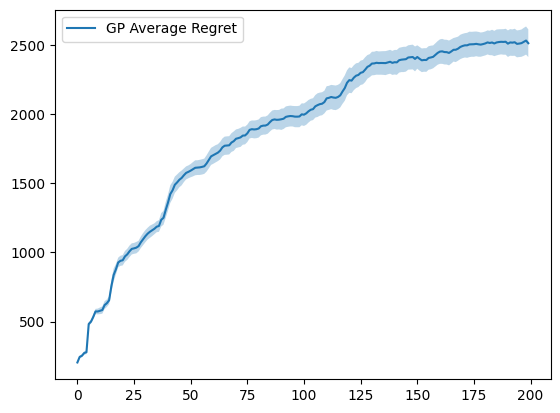

In [14]:
conversion_probability = lambda p: 1-p/24
reward_function = lambda price, n_sales: (price-cost)*n_sales

T = 200

min_price, max_price = 10, 20
n_customers = 100
cost = 10

scale = 2
reg = max(0.2,10/n_customers)

prices = np.linspace(min_price, max_price, 100)

# let's compute the clairvoyant
many_prices = np.linspace(min_price, max_price, 1000)
profit_curve = reward_function(many_prices, n_customers*conversion_probability(many_prices))
best_price_index = np.argmax(profit_curve)
best_price = many_prices[best_price_index]
expected_clairvoyant_rewards = np.repeat(profit_curve[best_price_index], T)

n_epochs = 20

gp_all_cumulative_regrets = []
for i in range(n_epochs):
    gp_agent = GPUCBAgent(T,scale=scale,reg=reg)

    np.random.seed(10*i)
    env = PricingEnvironment(conversion_probability=conversion_probability, cost=cost)

    gp_agent_rewards = []
    for t in range(T):
        p_t = gp_agent.pull_arm()
        p_t = rescale(p_t, min_price, max_price)
        d_t, r_t = env.round(p_t, n_t=n_customers)
        normalized_r_t = (r_t/max(prices-cost))/n_customers # normalized in [0,1]
        gp_agent.update(normalized_r_t)
        gp_agent_rewards.append(r_t)

    gp_all_cumulative_regrets.append(np.cumsum(expected_clairvoyant_rewards-gp_agent_rewards))


gp_all_cumulative_regrets = np.array(gp_all_cumulative_regrets)
gp_average_cumulative_regret = gp_all_cumulative_regrets.mean(axis=0)
gp_cumulative_regret_std = gp_all_cumulative_regrets.std(axis=0)

plt.plot(np.arange(T), gp_average_cumulative_regret, label='GP Average Regret')
plt.fill_between(np.arange(T),
                gp_average_cumulative_regret-gp_cumulative_regret_std/np.sqrt(n_epochs),
                gp_average_cumulative_regret+gp_cumulative_regret_std/np.sqrt(n_epochs),
                alpha=0.3)
plt.legend()
plt.show()

### Comparion with UCB1

In [15]:
class UCB1Agent:
    def __init__(self, K, T, range=1):
        self.K = K
        self.T = T
        self.range = range
        self.a_t = None
        self.average_rewards = np.zeros(K)
        self.N_pulls = np.zeros(K)
        self.t = 0
    
    def pull_arm(self):
        if self.t < self.K:
            self.a_t = self.t 
        else:
            ucbs = self.average_rewards + self.range*np.sqrt(np.log(self.T)/(2*self.N_pulls))
            self.a_t = np.argmax(ucbs)
        return self.a_t
    
    def update(self, r_t):
        self.N_pulls[self.a_t] += 1
        self.average_rewards[self.a_t] += (r_t - self.average_rewards[self.a_t])/self.N_pulls[self.a_t]
        self.t += 1

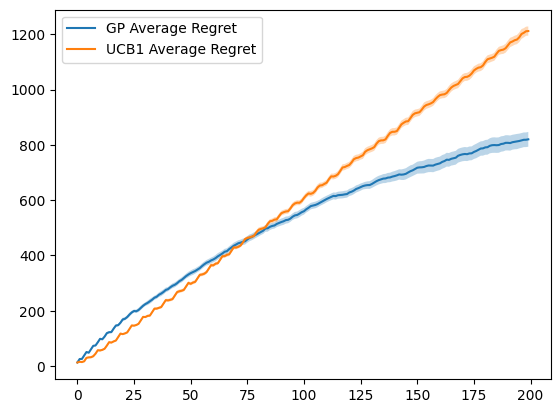

In [16]:
conversion_probability = lambda p: 1-p/20
reward_function = lambda price, n_sales: (price-cost)*n_sales

T = 200

min_price, max_price = 10, 20
n_customers = 10
cost = 10

scale = 2
reg = max(0.2,10/n_customers)

epsilon = T**(-0.33)
K = int(1/epsilon)
cover_prices = np.linspace(min_price, max_price, K)

prices = np.linspace(min_price, max_price, 100)

# let's compute the clairvoyant
many_prices = np.linspace(min_price, max_price, 1000)
profit_curve = reward_function(many_prices, n_customers*conversion_probability(many_prices))
best_price_index = np.argmax(profit_curve)
best_price = many_prices[best_price_index]
expected_clairvoyant_rewards = np.repeat(profit_curve[best_price_index], T)

n_epochs = 20

gp_all_cumulative_regrets = []
ucb_all_cumulative_regrets = []
for i in range(n_epochs):
    gp_agent = GPUCBAgent(T,scale=scale,reg=reg)
    ucb1_agent = UCB1Agent(K, T, range=maximum_profit)

    np.random.seed(10*i)
    env = PricingEnvironment(conversion_probability=conversion_probability, cost=cost)

    gp_agent_rewards = []
    ucb_agent_rewards = []
    for t in range(T):
        p_t = gp_agent.pull_arm()
        p_t = rescale(p_t, min_price, max_price)
        d_t, r_t = env.round(p_t, n_t=n_customers)
        normalized_r_t = (r_t/max(prices-cost))/n_customers # normalized in [0,1]
        gp_agent.update(normalized_r_t)
        gp_agent_rewards.append(r_t)

        p_t = ucb1_agent.pull_arm()
        p_t = cover_prices[p_t]
        d_t, r_t = env.round(p_t, n_t=n_customers)
        ucb1_agent.update(r_t)
        ucb_agent_rewards.append(r_t)

    gp_all_cumulative_regrets.append(np.cumsum(expected_clairvoyant_rewards-gp_agent_rewards))
    ucb_all_cumulative_regrets.append(np.cumsum(expected_clairvoyant_rewards-ucb_agent_rewards))


gp_all_cumulative_regrets = np.array(gp_all_cumulative_regrets)
gp_average_cumulative_regret = gp_all_cumulative_regrets.mean(axis=0)
gp_cumulative_regret_std = gp_all_cumulative_regrets.std(axis=0)

ucb_all_cumulative_regrets = np.array(ucb_all_cumulative_regrets)
ucb_average_cumulative_regret = ucb_all_cumulative_regrets.mean(axis=0)
ucb_cumulative_regret_std = ucb_all_cumulative_regrets.std(axis=0)

plt.plot(np.arange(T), gp_average_cumulative_regret, label='GP Average Regret')
plt.fill_between(np.arange(T),
                gp_average_cumulative_regret-gp_cumulative_regret_std/np.sqrt(n_epochs),
                gp_average_cumulative_regret+gp_cumulative_regret_std/np.sqrt(n_epochs),
                alpha=0.3)

plt.plot(np.arange(T), ucb_average_cumulative_regret, label='UCB1 Average Regret')
plt.fill_between(np.arange(T),
                ucb_average_cumulative_regret-ucb_cumulative_regret_std/np.sqrt(n_epochs),
                ucb_average_cumulative_regret+ucb_cumulative_regret_std/np.sqrt(n_epochs),
                alpha=0.3)

plt.legend()
plt.show()

### Regret of GP-UCB:
### $$ R_T = \mathcal{O}(\sqrt{T}\gamma_T) =  \mathcal{O}(\sqrt{T}\log(T)^{d+1})$$
### where $d$ is the dimension of the action space, in our case $d=1$. Note that the total information gain term scales exponentially with the dimension of the action space -> curse of dimensionality!

### Multi-dimensional action spaces ($d>1$) are very important in dynamic pricing, since they model the scenario in which a seller is offering multiple product, with possibly correlated demands. GP-UCB can be extended to the multi-dimensional scenario, see the reference above.